## 01. 회귀 기반 추천 시스템

회귀 기반 추천은 추천 문제를 “점수 예측 문제”로 바꾸어 해결하는 방식이다.

### 회귀 기반 추천 시스템흐름

1. 추천 후보를 준비한다.
2. 사용자 조건과 후보 정보를 모델에 넣는다.
3. 모델이 후보별 예상 점수를 예측한다.
4. 예측 점수가 높은 후보를 위로 정렬한다.
5. 정렬 결과의 상위 항목을 추천 결과로 사용한다.

예를 들어 여행지 추천에서는 사용자의 성별, 연령대, 여행 스타일, 이동수단, 후보 여행지 같은 정보를 입력으로 넣고, 해당 여행지에 대한 예상 만족도 점수를 예측한다.  
이후 예측 만족도가 높은 여행지를 위에서부터 추천한다.

---

**왜 회귀 모델로 추천을 만들 수 있는가?**

회귀 모델은 숫자를 예측하는 모델이다.  
추천 문제에서 예측하고 싶은 값을 “만족도”, “평점”, “구매 가능 점수”, “클릭 가능 점수”처럼 숫자로 정의하면 회귀 모델을 추천에 활용할 수 있다.

이 노트북에서는 `DGSTFN` 만족도 점수를 예측한다.  
따라서 모델이 출력하는 값은 “이 사용자가 이 방문지를 갔을 때 예상되는 만족도”로 해석한다.

---

**사용하는 모델: CatBoostRegressor**

CatBoostRegressor는 여러 개의 트리를 순서대로 학습하면서 오차를 줄여가는 부스팅 계열 회귀 모델이다.

범주형 feature를 비교적 편하게 다룰 수 있어 여행 지역, 이동수단, 여행 목적처럼 문자열이나 범주형 값이 많은 추천 예제에 잘 맞는다.

---

**확인할 평가 지표**

- MAE: 예측 만족도와 실제 만족도의 차이를 절댓값으로 평균낸 값이다. 낮을수록 좋음.
- RMSE: 큰 오차에 더 민감한 회귀 오차 지표이다. 낮을수록 좋음.
- R2: 평균값으로 예측하는 것보다 모델이 target 변화를 얼마나 더 잘 설명하는지 보는 지표이다. 1에 가까울수록 좋음.

추천 시스템에서는 평가 지표가 좋다고 바로 좋은 서비스가 되는 것은 아니다.  
모델이 예측한 점수를 기준으로 후보를 정렬했을 때 실제 사용자가 만족할 만한 추천 목록이 만들어지는지도 함께 봐야 한다.

---

**이 방식의 한계**

회귀 기반 추천은 “사용자와 후보 항목을 넣으면 점수를 예측한다”는 구조가 단순해서 이해하기 쉽다.  
하지만 사용자의 장기 행동 이력, 다른 사용자와의 유사성, 최신 선호 변화까지 모두 자동으로 반영하는 고도화된 추천 시스템은 아니다.

따라서 이 노트북은 추천 시스템 전체를 완성하는 단원이라기보다, 추천 시스템의 기본 구조인 “후보 생성 → 점수 예측 → 정렬”을 이해하기 위한 첫 번째 실습이다.


## 02. 추천 시스템을 가장 쉽게 시작하는 방법

추천 시스템을 처음 배울 때는 “복잡한 알고리즘”보다 “추천이 만들어지는 구조”를 먼저 보는 것이 좋다.

회귀 기반 추천은 추천 문제를 다음처럼 단순화한다.

```text
사용자 조건 + 후보 항목 정보 -> 예상 점수 예측 -> 점수순 정렬 -> 추천
```

여기서 중요한 점은 모델이 바로 “추천 목록”을 만들어주는 것이 아니라는 점이다.  
모델은 후보별 예상 점수를 예측하고, 우리는 그 점수를 기준으로 후보를 정렬해 추천 목록을 만든다.

이번 실습에서는 여행 데이터를 사용해 다음 질문에 답한다.

> 이 사용자 조건에서 어떤 방문지가 높은 만족도를 받을 가능성이 있는가?


## 03. 제주도 여행데이터

https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71584

이 데이터는 제주도 여행자의 기본 정보, 여행 스타일, 여행 동기, 방문지, 이동수단, 만족도 점수를 담고 있다.
여행자 조건과 후보 방문지 정보를 입력으로 넣고, `DGSTFN` 만족도 점수를 예측한 뒤 점수가 높은 방문지를 추천한다.

**컬럼 구성**

| 컬럼 | 의미 | 추천 모델에서의 역할 |
|---|---|---|
| `GENDER` | 여행자 성별 | 입력 feature |
| `AGE_GRP` | 여행자 연령대 코드 | 입력 feature |
| `TRAVEL_STYL_1` ~ `TRAVEL_STYL_8` | 여행 스타일 관련 설문 응답 코드값 | 입력 feature |
| `TRAVEL_MOTIVE_1` | 주요 여행 동기 코드 | 입력 feature |
| `TRAVEL_COMPANIONS_NUM` | 여행 동반자 수 | 입력 feature |
| `VISIT_AREA_NM` | 방문지 이름 | 추천 후보이자 입력 feature |
| `MVMN_NM` | 이동수단 이름 | 입력 feature |
| `DGSTFN` | 방문지 만족도 점수 | 예측할 target |

**학습 포인트**

- `GENDER`, `VISIT_AREA_NM`, `MVMN_NM`은 문자열 범주형 feature이다.
- `AGE_GRP`, `TRAVEL_STYL_*`, `TRAVEL_MOTIVE_1`, `TRAVEL_COMPANIONS_NUM`은 숫자로 보이지만 실제 의미는 코드값에 가까운 범주형 feature이다.
- `DGSTFN`은 모델이 맞혀야 하는 정답값이다. 이 값이 높게 예측되는 방문지를 추천 후보 상위에 배치한다.
- 따라서 이 예제는 “사용자 조건 + 후보 방문지 → 예상 만족도 점수”를 예측하는 회귀 기반 추천 문제이다.


## 04. 실습 환경 준비

- 라이브러리 import가 끝나면 데이터 처리, 모델 학습, 평가에 필요한 도구를 사용할 수 있음.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 05. 데이터 로드와 기본 확인

- 데이터 로드는 모델 학습 전에 컬럼 의미, 행/열 크기, target 분포를 확인하는 출발점임.


In [2]:
travel_df = pd.read_csv('data/travel.csv')
travel_df.head()


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM,DGSTFN
0,남,30.0,1.0,4.0,2.0,2.0,6.0,2.0,2.0,7.0,3.0,3.0,미스틱3도,자가용,5.0
1,남,20.0,4.0,1.0,5.0,1.0,1.0,4.0,1.0,6.0,3.0,1.0,에스제이렌트카,대중교통 등,4.0
2,여,50.0,4.0,1.0,2.0,4.0,3.0,3.0,2.0,3.0,1.0,3.0,법환식당,대중교통 등,5.0
3,남,30.0,1.0,1.0,1.0,5.0,6.0,3.0,5.0,7.0,7.0,3.0,에코랜드호텔,자가용,5.0
4,여,20.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,5.0,1.0,2.0,윤스타피자앤파스타,자가용,4.0


## 06. 범주형 feature 타입 정리

- 여행 스타일과 동기 컬럼을 모델에 전달하기 전에 일관된 정수형 범주 값으로 정리함.


In [3]:
travel_df[['AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
       'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
       'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM']] = travel_df.iloc[:, 1:-3].astype(int)

## 07. 데이터 구조 확인

- 자료형이 숫자인지 범주형인지, 결측치가 있는지에 따라 인코딩과 결측치 처리 방법이 달라짐.


In [4]:
travel_df.info()

# info() 결과
# 숫저 범주형 컬럼의 타입이 float -> int로 변경됨을 확인


<class 'pandas.DataFrame'>
RangeIndex: 34572 entries, 0 to 34571
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENDER                 34572 non-null  str    
 1   AGE_GRP                34572 non-null  int64  
 2   TRAVEL_STYL_1          34572 non-null  int64  
 3   TRAVEL_STYL_2          34572 non-null  int64  
 4   TRAVEL_STYL_3          34572 non-null  int64  
 5   TRAVEL_STYL_4          34572 non-null  int64  
 6   TRAVEL_STYL_5          34572 non-null  int64  
 7   TRAVEL_STYL_6          34572 non-null  int64  
 8   TRAVEL_STYL_7          34572 non-null  int64  
 9   TRAVEL_STYL_8          34572 non-null  int64  
 10  TRAVEL_MOTIVE_1        34572 non-null  int64  
 11  TRAVEL_COMPANIONS_NUM  34572 non-null  int64  
 12  VISIT_AREA_NM          34572 non-null  str    
 13  MVMN_NM                34572 non-null  str    
 14  DGSTFN                 34572 non-null  float64
dtypes: float64(1)

## 08. 기초 통계 확인

- 평균과 중앙값 차이, 최솟값/최댓값 범위를 보면 스케일링이나 이상치 처리가 필요한지 판단할 수 있음.


In [5]:
travel_df.describe()


,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,DGSTFN
count,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000
mean,28.470149,2.941137,2.405126,2.567801,3.332755,3.628312,3.657497,3.998814,4.877126,3.174679,1.489008,4.271144
std,9.096760,1.585247,1.520238,1.523111,1.587388,1.755299,1.655809,1.959919,1.784733,2.437807,1.621452,0.835598
min,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,4.000000,1.000000,0.000000,4.000000
50%,30.000000,3.000000,2.000000,2.000000,3.000000,4.000000,4.000000,4.000000,5.000000,2.000000,1.000000,4.000000
75%,30.000000,4.000000,3.000000,4.000000,4.000000,5.000000,5.000000,6.000000,6.000000,4.000000,2.000000,5.000000
max,60.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000,20.000000,5.000000


## 09. 분포와 집계 확인

- 분포가 치우치면 stratify, 평가지표 선택, 샘플링 전략이 달라질 수 있음.


In [6]:
travel_df['TRAVEL_COMPANIONS_NUM'].value_counts()

# 범주별 개수나 그룹별 통계를 확인해서 데이터 불균형과 패턴을 확인 가능
# 특정 동반자 수가 지나치게 많으면 모델이 해당 조건에 익숙해 지고 
# 동반자 수가 적은 조건에는 불안정 하게 예측을 하게 될 것이다
# -> 만약 불안정하게 예측된다면?
# -> 가중치 부여를 고려해봐야한다


TRAVEL_COMPANIONS_NUM
1     13864
0      9100
3      4749
2      4040
4      1241
5       709
6       287
7       216
8       154
9        91
10       39
12       31
13       19
17       14
14       13
11        4
20        1
Name: count, dtype: int64

## 10. 데이터 일부 확인

- head 결과는 값의 형태와 컬럼 의미를 빠르게 확인하는 용도이며, 전체 품질 판단은 info/describe와 함께 봐야 함.


In [7]:
print(travel_df.columns)

display(travel_df.head())


Index(['GENDER', 'AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
       'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
       'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM',
       'VISIT_AREA_NM', 'MVMN_NM', 'DGSTFN'],
      dtype='str')


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM,DGSTFN
0,남,30,1,4,2,2,6,2,2,7,3,3,미스틱3도,자가용,5.0
1,남,20,4,1,5,1,1,4,1,6,3,1,에스제이렌트카,대중교통 등,4.0
2,여,50,4,1,2,4,3,3,2,3,1,3,법환식당,대중교통 등,5.0
3,남,30,1,1,1,5,6,3,5,7,7,3,에코랜드호텔,자가용,5.0
4,여,20,5,3,3,3,3,3,3,5,1,2,윤스타피자앤파스타,자가용,4.0


## 11. CatBoost에 범주형 feature로 전달 입력 컬럼 목록 조회

In [11]:
# 여행 데이터 중 마지막 컬럼(만족도)를 제외한 모든 컬럼을 조회해서 
# list 형대로 변환
# * 만족 데이터는 정답(y)로 이용할 예정 

# X(입력값)으로 사용할 데이터 컬럼(feature) 이름
cat_coulumns = travel_df.columns[:-1].to_list()

## 12. 학습/평가 데이터 분리

In [18]:
from sklearn.model_selection import train_test_split

# # 입력값
X = travel_df[cat_coulumns]
# # 정답값
y = travel_df['DGSTFN'] # 만족도 점수

X_train, X_test, y_train ,y_test = train_test_split(
  X, 
  y, 
  test_size=0.2, 
  random_state=42,
  stratify=y
  )

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (27657, 14)
X_test shape: (6915, 14)
y_train shape: (27657,)
y_test shape: (6915,)


## 13. CatBoost 회귀 추천 모델 학습

CatBoost는 범주형 feature 처리를 지원하므로 여행 스타일처럼 문자/범주 성격이 강한 데이터에 활용하기 좋다.

CatBoostRegressor는 여행자 정보와 후보 방문지 정보를 입력받아 `DGSTFN` 만족도 점수를 예측한다.
즉, 모델의 출력값은 class가 아니라 숫자 점수이다.


- `n_estimators`: 순서대로 만들 트리 개수이다. 많을수록 복잡한 패턴을 학습할 수 있지만 시간이 오래 걸릴 수 있다.
- `depth`: 각 트리의 깊이이다. 깊을수록 복잡한 규칙을 만들 수 있지만 과대적합 위험이 커질 수 있다.
- `learning_rate`: 새 트리가 이전 오차를 얼마나 크게 보정할지 정하는 값이다.
- `loss_function='RMSE'`: 모델이 줄이려고 하는 손실 기준이다.


In [16]:
# !pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 4.5 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 4.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 2/3 [catboost]

In [19]:
from catboost import CatBoostRegressor, Pool
cat_features_name = list(cat_coulumns)

# catboost.Pool() : CatBosst 전용 객체 데이터
# X, y 데이터를 묶고, cat_features에 범주형 컬럼 목록을 전달 
# -> 이렇게 하면 CatBoost가 범주형 데이터를 내부 방식으로 인코딩하여 학습함
train_pool = Pool(X_train,
                  y_train,
                  cat_features=cat_features_name)
test_pool = Pool(X_test,
                  y_test,
                  cat_features=cat_features_name)

# CatBoostRegressor 객체 생성
cat_reg = CatBoostRegressor(
    n_estimators=5000,
    depth=5, # 트리 깊이
    # 학습률 : 오차를 줄이기 위해 가중치를 얼마나 업데이트할지 결정
    learning_rate=0.01, 
    # 손실함수 : 모델이 학습할 때 얼마나 틀렸는지를 계산하는 기준
    loss_function='RMSE', 
    random_seed=42, # 랜덤 시드
    # 평가 지표 : 검증 데이터에서 출력할 평가 지표 
    # RMSE : 평균 제곱근 오차(Root Mean Squared Error)? 
    eval_metric='RMSE', 
)

# CatBoost 모델 학습
# verbose=50 : 50회 학습마다 로그를 출력
# eval_set=[test_pool] : test_pool 데이터를 이용해서 모델 검증 + 지표(RNSE) 기록
# 검증 데이터셋을 지정하여 학습 중에 평가 지표를 계산
cat_reg.fit(train_pool, eval_set=[test_pool], verbose=50)

0:	learn: 0.8354564	test: 0.8350696	best: 0.8350696 (0)	total: 107ms	remaining: 8m 55s
50:	learn: 0.8241947	test: 0.8222845	best: 0.8222845 (50)	total: 1000ms	remaining: 1m 36s
100:	learn: 0.8170814	test: 0.8141621	best: 0.8141621 (100)	total: 1.89s	remaining: 1m 31s
150:	learn: 0.8116872	test: 0.8081527	best: 0.8081527 (150)	total: 2.79s	remaining: 1m 29s
200:	learn: 0.8072414	test: 0.8034084	best: 0.8034084 (200)	total: 3.71s	remaining: 1m 28s
250:	learn: 0.8033536	test: 0.7990981	best: 0.7990981 (250)	total: 4.74s	remaining: 1m 29s
300:	learn: 0.7986087	test: 0.7939838	best: 0.7939838 (300)	total: 5.78s	remaining: 1m 30s
350:	learn: 0.7948689	test: 0.7900594	best: 0.7900594 (350)	total: 6.86s	remaining: 1m 30s
400:	learn: 0.7919746	test: 0.7870131	best: 0.7870131 (400)	total: 8.02s	remaining: 1m 31s
450:	learn: 0.7896343	test: 0.7846348	best: 0.7846348 (450)	total: 9.24s	remaining: 1m 33s
500:	learn: 0.7877004	test: 0.7826531	best: 0.7826531 (500)	total: 10.3s	remaining: 1m 32s
550:

CatBoostRegressor(depth=5, eval_metric='RMSE', learning_rate=0.01, loss_function='RMSE', n_estimators=5000, random_seed=42)

## 14. 학습 과정 시각화

학습 로그를 그래프로 그리면 반복 횟수가 늘어날 때 훈련 오차와 검증 오차가 어떻게 바뀌는지 볼 수 있다.

- Train RMSE: 모델이 학습 데이터에 얼마나 맞는지 보여준다.
- Validation RMSE: 처음 보는 데이터에 대한 예측 오차를 보여준다.
- Train RMSE만 낮고 Validation RMSE가 높으면 학습 데이터를 과하게 외운 상태일 수 있다.


dict_keys(['learn', 'validation'])


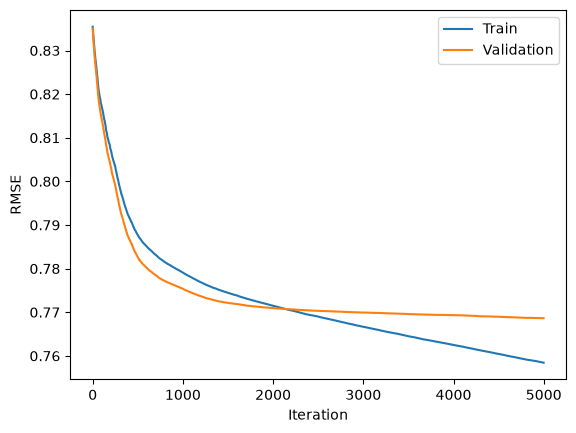

In [23]:
evals_result =  cat_reg.get_evals_result()
print(evals_result.keys())

# evals_result['learn']['RMSE']: 학습 데이터 RMSE 변화.
# evals_result['validation']['RMSE']: 평가 데이터 RMSE 변화.
plt.plot(evals_result['learn']['RMSE'], label='Train')
plt.plot(evals_result['validation']['RMSE'], label='Validation')
plt.ylabel('RMSE')
plt.xlabel('Iteration')
plt.legend()
plt.show()

# Train과 Test간의 오차는 있지만 감소하는 추세 
# == 모델이 학습을 할수록 예측 성능이 좋아지고 있따 

## 15. Feature 중요도 확인

Feature 중요도는 모델이 예측할 때 어떤 입력 변수를 많이 활용했는지 보여준다.

추천 시스템에서는 “왜 이 항목이 추천되었는가?”를 설명해야 하는 경우가 많다.  
예를 들어 방문지 이름, 이동수단, 여행 스타일 중 어떤 정보가 만족도 예측에 많이 쓰였는지 확인하면 모델의 판단 근거를 조금 더 설명할 수 있다.

CatBoost 같은 트리 기반 모델에서 중요도는 보통 분기와 손실 감소에 얼마나 기여했는지 기준으로 계산된다.  
중요도가 높다고 해서 반드시 만족도의 원인이라는 뜻은 아니며, 모델이 예측에 자주 참고한 변수로 해석하는 것이 안전하다.


In [27]:
feat_importances_df = pd.DataFrame({
  'colum': X_train.columns,
  'importance': cat_reg.get_feature_importance(train_pool)
})

display(feat_importances_df.sort_values(by='importance', ascending=False))

,colum,importance
12,VISIT_AREA_NM,17.959368
9,TRAVEL_STYL_8,10.388304
5,TRAVEL_STYL_4,9.102819
6,TRAVEL_STYL_5,8.544552
10,TRAVEL_MOTIVE_1,7.918268
8,TRAVEL_STYL_7,7.845504
7,TRAVEL_STYL_6,7.641748
2,TRAVEL_STYL_1,7.351253
1,AGE_GRP,6.468771
3,TRAVEL_STYL_2,6.070397


## 16. 예측과 점수 확인

회귀 기반 추천에서는 모델이 예측한 숫자 점수가 추천 정렬의 기준이 된다.  
따라서 추천 함수를 만들기 전에, 이 예측 점수가 어느 정도 믿을 만한지 먼저 확인해야 한다.

여기서 예측 점수는 확률이 아니다.  
`DGSTFN` 만족도 점수를 예측한 값이므로 “이 후보 방문지에 대해 모델이 예상한 만족도”로 해석한다.

- MAE: 평균적으로 몇 점 정도 틀리는지 직관적으로 볼 수 있음.
- RMSE: 큰 오차를 더 강하게 반영함.
- R2: 모델이 target 변화를 얼마나 설명하는지 확인함.

추천에서는 단일 샘플 하나를 맞혔는지보다, 여러 후보의 예측 점수를 비교했을 때 의미 있는 순서가 만들어지는지가 중요하다.


In [34]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# sklearn.metrics를 이용해서 수치를 확인해려면 
# y 와 y_pred 가 필요함

y_test_pred = cat_reg.predict(X_test)
mae = mean_absolute_error(y_test, y_test_pred)

rmse = np.sqrt(root_mean_squared_error(y_test, y_test_pred))

r2 = r2_score(y_test, y_test_pred)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

# 평가 데이터와 실제 만족도를 비교 
sample_X = X_test.iloc[[0]] # Test 입력밧 중 0번 행만 가져오기 
sample_y = y_test.iloc[[0]] # Test 실제값 중 0번 행만 가져오기
sample_pred = cat_reg.predict(sample_X)[0] # 예측값

display(sample_X)
print('실제 만족도 : ', sample_y.values[0])
print('예측 만족도 : ', sample_pred)

# 실제 만족도와 예측 만족도 MAE오차 범위와 유사하게 형성되면 
# 모델 학습은 잘 된것으로 생각할 수 있음
# 다만, 학습이 잘 되었다고 해서 모델의 성능이 좋다고는 판한하기 어렵다 
# -> 전체 평가 지표를 확인해볼 필요가 있음

MAE: 0.5743
RMSE: 0.8767
R2: 0.1533


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM
28442,남,60,1,1,5,3,1,5,1,6,2,1,로얄엠포리움호텔,자가용


실제 만족도 :  3.0
예측 만족도 :  3.5545568958418343


### 추천 함수

추천 함수는 “후보 장소를 하나씩 바꿔 넣어 예측 만족도를 계산하고, 점수가 높은 장소를 정렬하는 함수”이다.

처리 흐름은 다음과 같다.

1. 사용자 조건은 고정한다.
2. 후보 방문지만 하나씩 바꾼다.
3. 각 후보 방문지에 대한 예상 만족도를 예측한다.
4. 예측 만족도가 높은 순서로 정렬해 상위 N개를 추천한다.

이 과정에서 모델은 매번 “사용자 조건 + 후보 방문지” 조합에 대해 만족도 점수를 예측한다.  
즉, 추천 함수는 모델의 `predict()` 결과를 여러 번 모아서 순위를 만드는 역할을 한다.


## 17. 추천 후보가 될 전체 방문지 목록 확인

In [35]:
visit_areas = travel_df['VISIT_AREA_NM'].unique()
print(f'방문 지역 수 : {visit_areas}')

# 학습된 모델에 사용자 조건을 고정한 뒤 
# 방문지 목록을 하나씩 바꿔 넣으면서 만족도를 예측



방문 지역 수 : <StringArray>
[        '미스틱3도',       '에스제이렌트카',          '법환식당',        '에코랜드호텔',
     '윤스타피자앤파스타',      '서정리역 1호선',          '동문식당',          '해녀식당',
         '알맞은시간',          '애월온기',
 ...
        '제주초계한우',        '숲속의컨벤션',  '제주신화월드 S BAR',         '월미전망대',
         '네이처파크',           '고옥정',  '네스트호텔 쿤스트라운지',        '제이스바버샵',
 '블라제리조트 전기차충전소',           '미미슈']
Length: 10711, dtype: str


## 18. 추천 함수에 넣을 사용자 입력값 구조 확인

In [36]:
print(X_test.iloc[0].values)

# 장소가 입력 데이터의 12번째 컬럼임을 확인한다 (0 ~ 13 : 12번째가 장소데이터)
# [중요] 입력 데이터의 순서는 학습 데이터와 동일해야한다 

['남' np.int64(60) np.int64(1) np.int64(1) np.int64(5) np.int64(3)
 np.int64(1) np.int64(5) np.int64(1) np.int64(6) np.int64(2) np.int64(1)
 '로얄엠포리움호텔' '자가용']


## 19. 예측 점수 기반 추천 결과 생성

이제 학습된 CatBoost 모델을 추천 함수 안에서 사용한다.

중요한 해석 포인트는 다음이다.

- `user_input`: 한 명의 사용자 조건과 후보 방문지 자리를 담은 입력값임.
- `candidate_input[-2]`: 방문지 이름이 들어가는 위치임.
- `dgstfn_pred`: 모델이 예측한 예상 만족도 점수임.
- 추천 결과는 `dgstfn_pred`가 높은 순서로 정렬됨.

따라서 최종 표의 첫 번째 행은 “현재 사용자 조건에서 모델이 가장 높은 만족도를 예상한 방문지”로 해석한다.


In [59]:
# 장소 추런 함수
# - 사용자 입력을 전달 받아 cat_boost 모델을 이용해 장소별 만족도 예측
# - 결과로 보여줄 장소의 수(추천 수)는 topn으로 지정
def recommend_visit_area(user_input, topn=10):
  
  # 만족도 예측 결과를 저장할 list
  dgstfn_result = []
  
  # 방문지 목록의 모든 방문지와 user_input을 이용해서
  # 만족도 예측
  
  for area in visit_areas:
    # 원본 유지를 위해 user_input 복사
    candidate_input = user_input.copy()
    
    # 사용자 입력(14 컬럼) 값 중 장소 컬럼(뒤에서 두 번째) 값을 
    # area 값으로 지정
    # 뒤에서 두번째 즉, 12번째
    candidate_input[-2] = area
    
    # CatBoost 모델은 학숩, 예측 시 값이 DataFrame 형태의 2차원 데이터로 만들야 한다
    candidate_df = pd.DataFrame(
      [candidate_input],
      columns=cat_coulumns
      )
    
    # 현재 area에 대한 만족도 예측
    # dgstfn = cat_reg.predict(candidate_df)[0]
    dgstfn = cat_reg.predict(candidate_df)[0]
    dgstfn_result.append(dgstfn)
    
  # 방문지 목록과 만족도 목록을 하나의 표로 묶기 
  results_df = pd.DataFrame({
    'visit_areas': visit_areas,
    'dgstfn': dgstfn_result
  })
  
  # 추천을 위해 만족대 내림 차순 정렬
  results_df = results_df.sort_values('dgstfn', ascending=False)
  
  return results_df.head(topn)

user_input = ['남', 60,    1, 1, 5, 3, 1, 5, 1, 6,     2, 1, 'XXXXXXXXXX', '자가용']
recommend_visit_area(user_input, topn=10)

,visit_areas,dgstfn
1933,폴바셋 제주용담DT점,4.279562
146,숙성도 함덕점,4.272669
676,파라다이스시티,4.256411
1828,한라산국립공원 성판악탐방로,4.247516
4661,안면도수목원,4.246842
272,아침미소목장,4.245485
725,롯데호텔 제주,4.240522
2314,회춘 애월점,4.238478
2300,그랜드하얏트제주,4.238000
216,제주신라호텔,4.236923


## 20. 여러 사용자 조건으로 예측해보기

하나의 사용자 입력만 확인하면 추천 함수가 실제로 사용자 조건에 따라 달라지는지 보기 어렵다.

이번 셀에서는 평가 데이터에서 사용자 조건 몇 개를 가져와, 여러 후보 방문지에 대한 예상 만족도를 비교한다.  
이렇게 보면 “사용자 조건이 달라지면 같은 방문지라도 예측 만족도가 달라질 수 있다”는 점을 확인할 수 있다.

주의할 점은 이번 셀이 **전체 방문지 중 최종 추천을 다시 구하는 셀은 아니라는 것**이다.  
아래 코드에서는 `value_counts().head(5)`로 데이터에 자주 등장한 방문지 5개만 골라 비교한다.

따라서 이 셀의 결과는 다음처럼 해석한다.

```text
전체 방문지 중 추천 결과가 아니라,
선택한 후보 5개 안에서 사용자별 예상 만족도를 비교한 결과이다.
```

확인할 내용은 다음이다.

- 행: 서로 다른 사용자 조건
- 열: 비교 대상으로 선택한 후보 방문지 5개
- 값: CatBoost 모델이 예측한 예상 만족도 점수

점수가 높은 후보일수록 현재 사용자 조건에서 우선 추천될 가능성이 높다.  
다만 후보를 5개로 제한했기 때문에, 이 표에 없는 다른 방문지가 실제 전체 추천에서는 더 높은 점수를 받을 수도 있다.


In [61]:
# 입력된 사용자가 전달 받은 장소 중 만족도가 높은 순서로 반환
def recommend_visit_area_input_areas(user_input, visit_areas):

  dgstfn_results = []

  for area in visit_areas:
      candidate_input = user_input.copy()
      candidate_input[-2] = area
      
      candidate_df = pd.DataFrame(
          [candidate_input],
          columns=cat_coulumns
      )

      dgstfn = cat_reg.predict(candidate_df)[0]
      dgstfn_results.append(dgstfn)

  results_df = pd.DataFrame({
      'visit_area': visit_areas,
      'dgstfn_pred': dgstfn_results
  })

  result_df = results_df.sort_values('dgstfn_pred', ascending=False)

  return result_df 

In [70]:
# 사용자 샘플
sample_users_df = X_test.head(3)

# 장소 지정
# display( pd.DataFrame(visit_areas) )

sample_visit_areas = ['해녀식당', '아일랜드 리솜', '네스트호텔 쿤스트라운지', '섭지코지', '뽀로로앤타요테마파크제주']
recommend_results = []

for user_idx, user_info in sample_users_df.iterrows():
  # print(user_idx)
  # print(user_info)
  
  # 시리즈 -> 리스트 변환
  # 데이터 프레임의 단위객체는 시리즈 -> 리스트로 변환해서 가져옴
  user_input = user_info.tolist()
  # print(user_input)
  
  result_df = recommend_visit_area_input_areas(
    user_input,
    sample_visit_areas
  )
  
  # 사용자 구분을 위해서 user_idx 추가
  result_df['user_idx'] = user_idx
  
  recommend_results.append(result_df)
  
# list[DataFreame] -> DataFrame으로 합침
recomment_result_df = pd.concat(recommend_results, ignore_index=True)
recomment_result_df = recomment_result_df[['user_idx', 'visit_area', 'dgstfn_pred']]
display(recomment_result_df)

,user_idx,visit_area,dgstfn_pred
0,28442,아일랜드 리솜,4.025263
1,28442,섭지코지,3.975381
2,28442,뽀로로앤타요테마파크제주,3.927850
3,28442,해녀식당,3.920829
4,28442,네스트호텔 쿤스트라운지,3.794735
5,22538,뽀로로앤타요테마파크제주,4.450821
6,22538,아일랜드 리솜,4.450199
7,22538,섭지코지,4.413449
8,22538,해녀식당,4.397750
9,22538,네스트호텔 쿤스트라운지,4.266886
